# Custom-Trained Image Embedding Model — Full Training Notebook

This notebook trains a **Convolutional Neural Network (CNN) from scratch**
on the CIFAR-100 dataset, and uses it to convert images into numerical
vectors (embeddings). These vectors are the core building block for the
image retrieval system (FAISS-based search).

**What this notebook demonstrates, step by step:**
1. Dataset loading and visualization
2. CNN model definition
3. Training the model, with live loss/accuracy plots
4. Testing: feeding in one image and inspecting the output vector
5. Visualizing the learned embedding space (t-SNE)
6. A small similarity-search demo (retrieval in action)
7. Saving the trained model

> Runtime: In Colab, go to **Runtime → Change runtime type → GPU** for
> much faster training (not required, but recommended).


## 1. Setup & Imports

In [ ]:
# Core libraries (torch/torchvision are pre-installed on Colab)
!pip install -q faiss-cpu


In [ ]:
import time
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import faiss
from sklearn.manifold import TSNE

from tqdm.notebook import tqdm

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


## 2. Load the Dataset (CIFAR-100)

CIFAR-100 has 60,000 images (50,000 train / 10,000 test) across 100
classes — a good general-purpose dataset for training an embedding
model from scratch without needing to collect your own images.

In [ ]:
IMAGE_SIZE = 64  # resize CIFAR's native 32x32 images up to 64x64

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

train_set = datasets.CIFAR100(root="./data", train=True, download=True, transform=train_transform)
test_set  = datasets.CIFAR100(root="./data", train=False, download=True, transform=test_transform)

class_names = train_set.classes

print(f"Training images: {len(train_set)}")
print(f"Test images:     {len(test_set)}")
print(f"Number of classes: {len(class_names)}")
print(f"Example class names: {class_names[:10]}")


100%|██████████| 169M/169M [41:21<00:00, 68.1kB/s]


Training images: 50000
Test images:     10000
Number of classes: 100
Example class names: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle']


### 2.1 Visualize a sample grid of training images

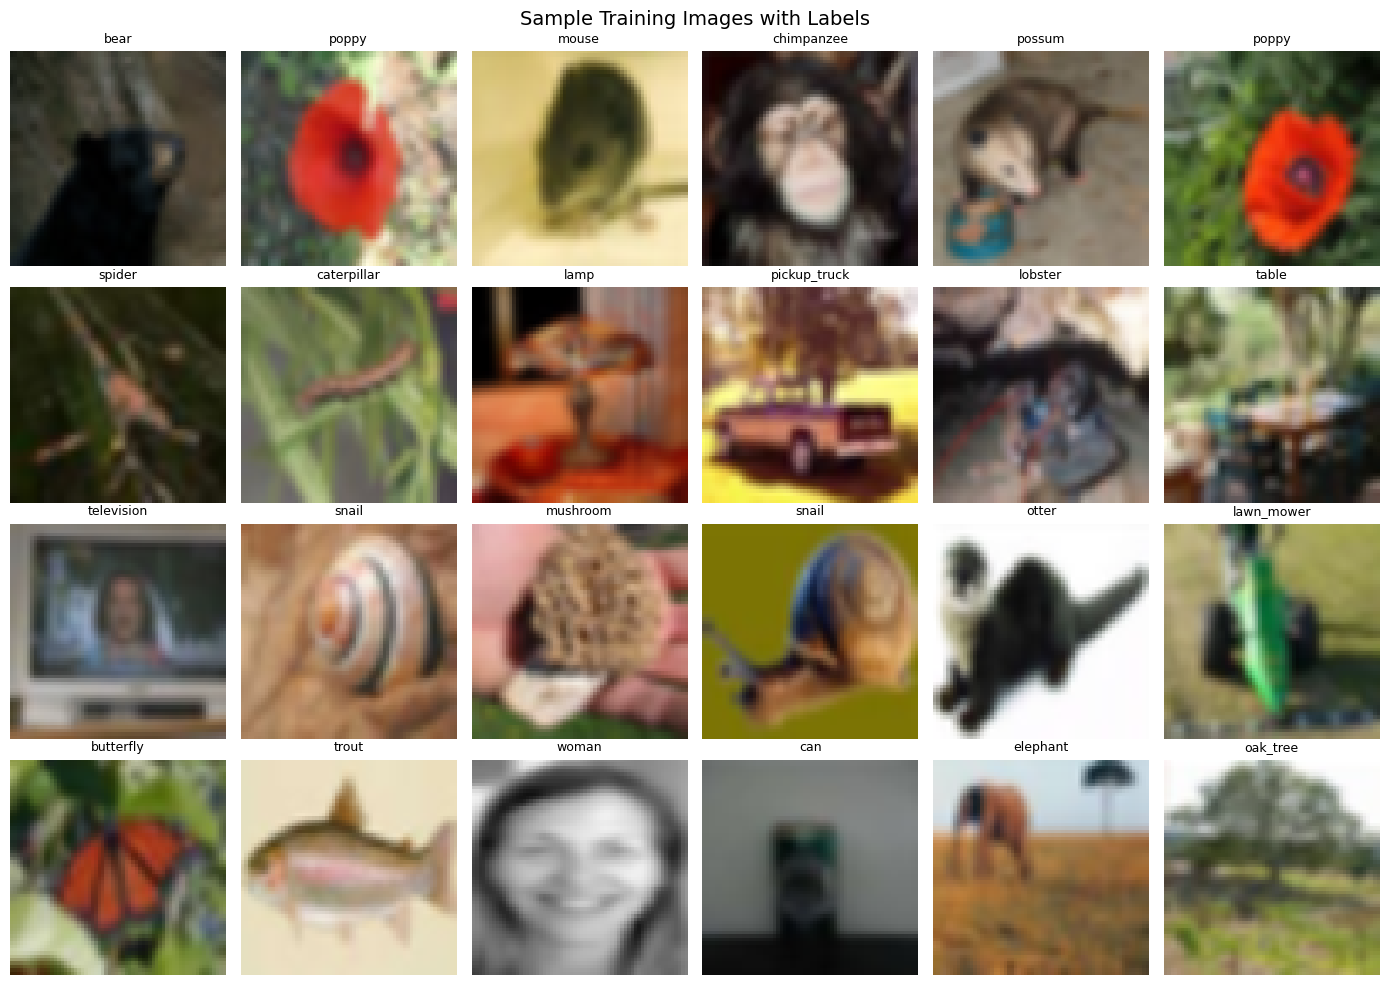

In [ ]:
def denormalize(img_tensor):
    img = img_tensor.numpy().transpose(1, 2, 0)
    img = img * 0.5 + 0.5  # undo normalization
    return np.clip(img, 0, 1)

fig, axes = plt.subplots(4, 6, figsize=(14, 10))
indices = random.sample(range(len(train_set)), 24)

for ax, idx in zip(axes.flatten(), indices):
    img_tensor, label = train_set[idx]
    ax.imshow(denormalize(img_tensor))
    ax.set_title(class_names[label], fontsize=9)
    ax.axis("off")

plt.suptitle("Sample Training Images with Labels", fontsize=14)
plt.tight_layout()
plt.show()


### 2.2 Class distribution

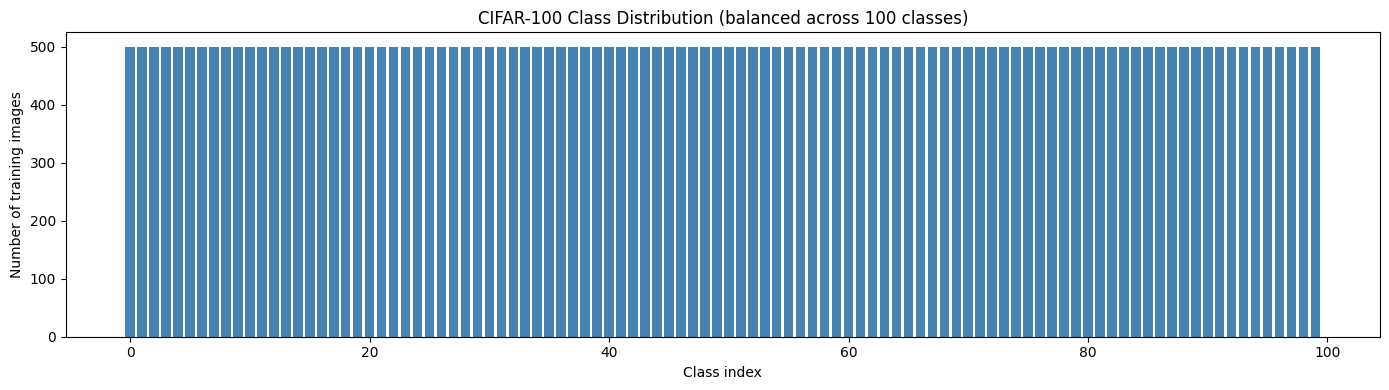

Min images per class: 500  |  Max images per class: 500


In [ ]:
labels = [label for _, label in train_set]
counts = np.bincount(labels)

plt.figure(figsize=(14, 4))
plt.bar(range(len(counts)), counts, color="steelblue")
plt.xlabel("Class index")
plt.ylabel("Number of training images")
plt.title("CIFAR-100 Class Distribution (balanced across 100 classes)")
plt.tight_layout()
plt.show()

print(f"Min images per class: {counts.min()}  |  Max images per class: {counts.max()}")


## 3. Define the CNN Architecture

This is the model that converts an image into a vector (embedding).
It has:
- A **feature extractor**: 4 conv blocks that progressively shrink the
  image while learning richer visual features.
- An **embedding layer**: compresses the final feature map into a
  single 256-number vector — this is the "fingerprint" we care about.
- A **classifier head**: only used during training, to force the
  network to learn something meaningful. We discard it afterward.

In [ ]:
EMBEDDING_DIM = 256

class EmbeddingCNN(nn.Module):
    def __init__(self, embedding_dim=EMBEDDING_DIM, num_classes=100):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.embedding_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, embedding_dim),
            nn.ReLU(),
        )
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x, return_embedding=False):
        x = self.features(x)
        embedding = self.embedding_layer(x)
        if return_embedding:
            return embedding
        logits = self.classifier(embedding)
        return logits, embedding


model = EmbeddingCNN(embedding_dim=EMBEDDING_DIM, num_classes=len(class_names)).to(DEVICE)

num_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal trainable parameters: {num_params:,}")


EmbeddingCNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats

## 4. Train the Model

In [ ]:
EPOCHS = 15
BATCH_SIZE = 128
LEARNING_RATE = 1e-3

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)

print(f"Training for {EPOCHS} epochs on {DEVICE} ...")


Training for 15 epochs on cuda ...


In [ ]:
train_losses = []
test_accuracies = []
best_acc = 0.0

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        logits, _ = model(images, return_embedding=False)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    scheduler.step()
    epoch_loss = running_loss / len(train_set)
    train_losses.append(epoch_loss)

    # Evaluate on test set
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits, _ = model(images, return_embedding=False)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    test_acc = correct / total
    test_accuracies.append(test_acc)

    print(f"Epoch {epoch}: train_loss={epoch_loss:.4f}  test_accuracy={test_acc:.4f}")

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save({
            "model_state_dict": model.state_dict(),
            "embedding_dim": EMBEDDING_DIM,
            "class_names": class_names,
            "test_accuracy": test_acc,
        }, "embedding_model.pth")

total_time = time.time() - start_time
print(f"\nTraining complete in {total_time/60:.1f} minutes. Best test accuracy: {best_acc:.4f}")


Epoch 1/15:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 1: train_loss=3.6018  test_accuracy=0.2456


Epoch 2/15:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 2: train_loss=2.7564  test_accuracy=0.3331


Epoch 3/15:   0%|          | 0/391 [00:00<?, ?it/s]

...

Epoch 13: train_loss=0.8847  test_accuracy=0.5696


Epoch 14/15:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 14: train_loss=0.8145  test_accuracy=0.5703


Epoch 15/15:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 15: train_loss=0.6637  test_accuracy=0.5926

Training complete in 8.0 minutes. Best test accuracy: 0.5926


### 4.1 Training curves

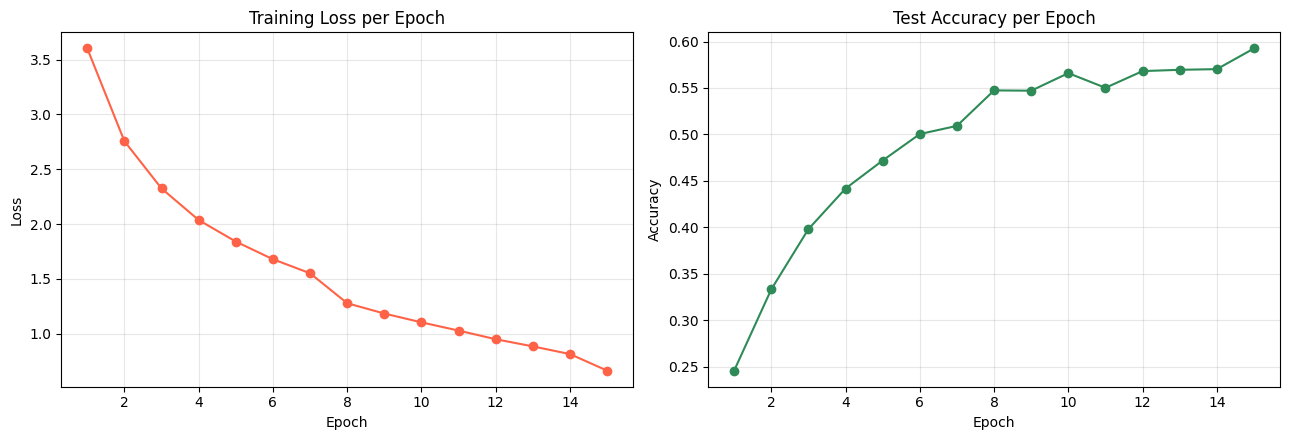

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(range(1, EPOCHS + 1), train_losses, marker="o", color="tomato")
axes[0].set_title("Training Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, EPOCHS + 1), test_accuracies, marker="o", color="seagreen")
axes[1].set_title("Test Accuracy per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Test: Convert a Single Image into a Vector

This is the core function the whole retrieval project depends on:
**image in → vector out**. Let's run it on one test image and inspect
the actual numbers produced.

In [ ]:
# Reload the BEST checkpoint (in case the last epoch wasn't the best)
checkpoint = torch.load("embedding_model.pth", map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(f"Loaded best checkpoint (test accuracy: {checkpoint['test_accuracy']:.4f})")


Loaded best checkpoint (test accuracy: 0.5926)


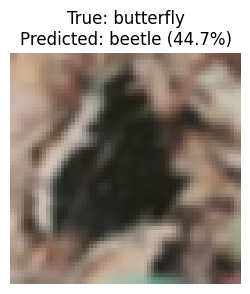

Output embedding vector shape: (256,)
First 20 values of the vector:
[ 3.9806871  0.         0.         0.        12.395082   0.
  0.         0.         0.         0.         9.5547695  0.
  0.         0.         0.        11.012333   0.         0.
  5.465199   4.6934376]


In [ ]:
# Pick one test image
test_img_tensor, true_label_idx = test_set[7]
input_batch = test_img_tensor.unsqueeze(0).to(DEVICE)  # add batch dimension

with torch.no_grad():
    logits, embedding = model(input_batch, return_embedding=False)
    predicted_idx = logits.argmax(dim=1).item()
    confidence = F.softmax(logits, dim=1)[0, predicted_idx].item()

embedding_vector = embedding.cpu().numpy()[0]

# Show the image
plt.figure(figsize=(3, 3))
plt.imshow(denormalize(test_img_tensor))
plt.title(f"True: {class_names[true_label_idx]}\nPredicted: {class_names[predicted_idx]} ({confidence:.1%})")
plt.axis("off")
plt.show()

print(f"Output embedding vector shape: {embedding_vector.shape}")
print(f"First 20 values of the vector:\n{embedding_vector[:20]}")


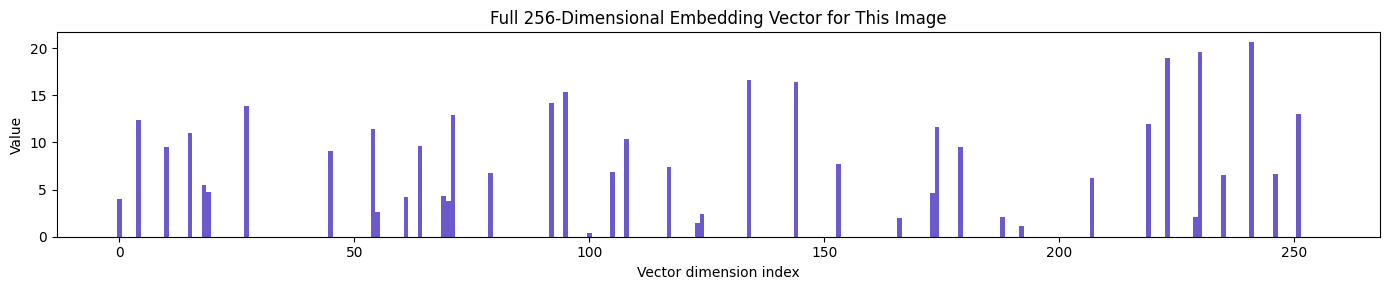

In [ ]:
# Visualize the full embedding vector as a bar plot
plt.figure(figsize=(14, 3))
plt.bar(range(len(embedding_vector)), embedding_vector, color="slateblue", width=1.0)
plt.title("Full 256-Dimensional Embedding Vector for This Image")
plt.xlabel("Vector dimension index")
plt.ylabel("Value")
plt.tight_layout()
plt.show()


### 5.1 (Optional) Try it on your own uploaded image

Saving closeup-shot-beautiful-butterfly-with-interesting-textures-orange-petaled-flower.jpg to closeup-shot-beautiful-butterfly-with-interesting-textures-orange-petaled-flower.jpg


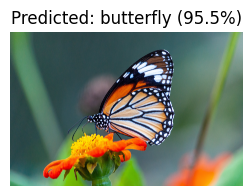

Embedding vector shape: (256,)
First 15 values: [ 0.        0.        0.        0.       16.567825  0.        0.
  0.        0.        0.       10.695974  0.        0.        0.
  0.      ]


In [ ]:
from google.colab import files
from PIL import Image
import io

uploaded = files.upload()  # opens a file picker in Colab

for filename in uploaded.keys():
    img = Image.open(io.BytesIO(uploaded[filename])).convert("RGB")
    input_tensor = test_transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits, embedding = model(input_tensor, return_embedding=False)
        pred_idx = logits.argmax(dim=1).item()
        conf = F.softmax(logits, dim=1)[0, pred_idx].item()

    vec = embedding.cpu().numpy()[0]

    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.title(f"Predicted: {class_names[pred_idx]} ({conf:.1%})")
    plt.axis("off")
    plt.show()

    print(f"Embedding vector shape: {vec.shape}")
    print(f"First 15 values: {vec[:15]}")


## 6. Visualize the Embedding Space (t-SNE)

If the model learned useful features, images from the same class
should cluster together in vector space — even though the model was
never explicitly told "cluster these together," only "classify this
correctly." This plot is strong visual proof the embeddings are
meaningful, not random numbers.

In [ ]:
# Compute embeddings for a subset of test images (t-SNE is slow on large sets)
NUM_SAMPLES = 1500
NUM_CLASSES_TO_SHOW = 10  # keep the plot readable

subset_indices = random.sample(range(len(test_set)), NUM_SAMPLES)

all_embeddings = []
all_labels = []

model.eval()
with torch.no_grad():
    for idx in tqdm(subset_indices, desc="Computing embeddings"):
        img_tensor, label = test_set[idx]
        if label >= NUM_CLASSES_TO_SHOW:
            continue
        input_batch = img_tensor.unsqueeze(0).to(DEVICE)
        emb = model(input_batch, return_embedding=True)
        all_embeddings.append(emb.cpu().numpy()[0])
        all_labels.append(label)

all_embeddings = np.array(all_embeddings)
all_labels = np.array(all_labels)
print(f"Computed {len(all_embeddings)} embeddings across {NUM_CLASSES_TO_SHOW} classes")


Computing embeddings:   0%|          | 0/1500 [00:00<?, ?it/s]

Computed 164 embeddings across 10 classes


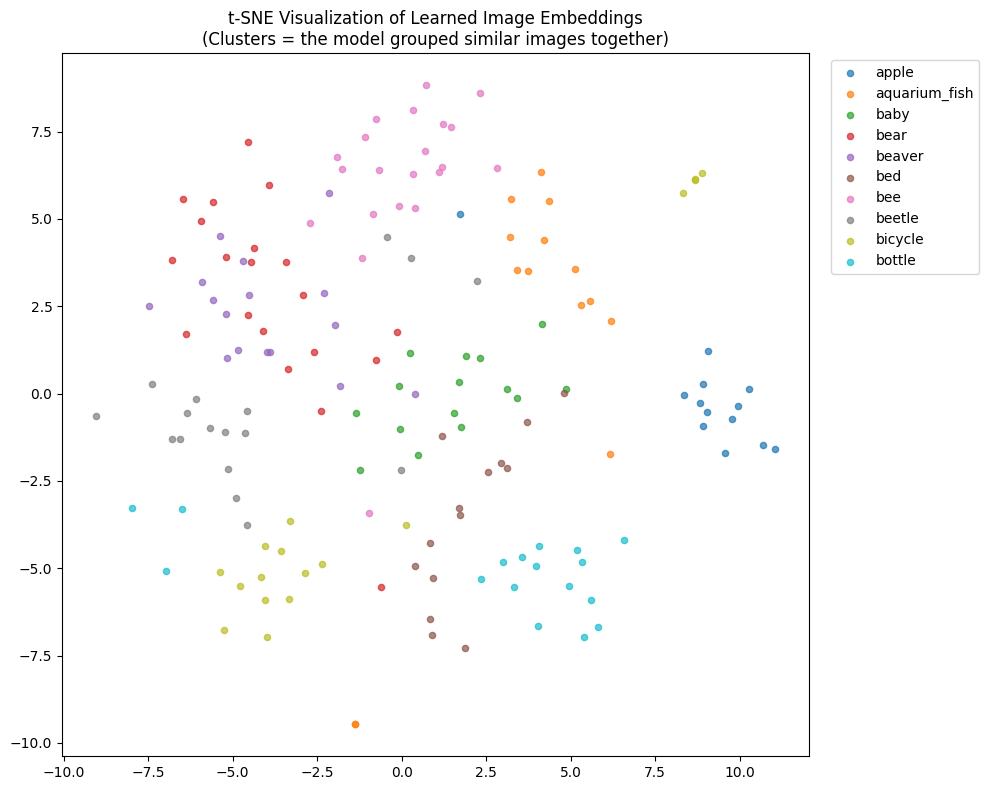

In [ ]:
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
embeddings_2d = tsne.fit_transform(all_embeddings)

plt.figure(figsize=(10, 8))
cmap = plt.get_cmap("tab10")

for class_idx in range(NUM_CLASSES_TO_SHOW):
    mask = all_labels == class_idx
    plt.scatter(
        embeddings_2d[mask, 0], embeddings_2d[mask, 1],
        label=class_names[class_idx], alpha=0.7, s=20, color=cmap(class_idx),
    )

plt.title("t-SNE Visualization of Learned Image Embeddings\n(Clusters = the model grouped similar images together)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 7. Mini Similarity Search Demo

This mirrors what the full FAISS-based retrieval project does: build
an index of image vectors, then given a new query image, find the
most visually similar images already in the index.

In [ ]:
# Build a small FAISS index from 300 test images
GALLERY_SIZE = 300
gallery_indices = random.sample(range(len(test_set)), GALLERY_SIZE)

gallery_vectors = []
gallery_images = []
gallery_labels = []

model.eval()
with torch.no_grad():
    for idx in gallery_indices:
        img_tensor, label = test_set[idx]
        input_batch = img_tensor.unsqueeze(0).to(DEVICE)
        emb = model(input_batch, return_embedding=True).cpu().numpy()[0]
        gallery_vectors.append(emb)
        gallery_images.append(img_tensor)
        gallery_labels.append(label)

gallery_vectors = np.array(gallery_vectors).astype("float32")
faiss.normalize_L2(gallery_vectors)

index = faiss.IndexFlatIP(gallery_vectors.shape[1])
index.add(gallery_vectors)

print(f"Built FAISS index with {index.ntotal} image vectors")


Built FAISS index with 300 image vectors


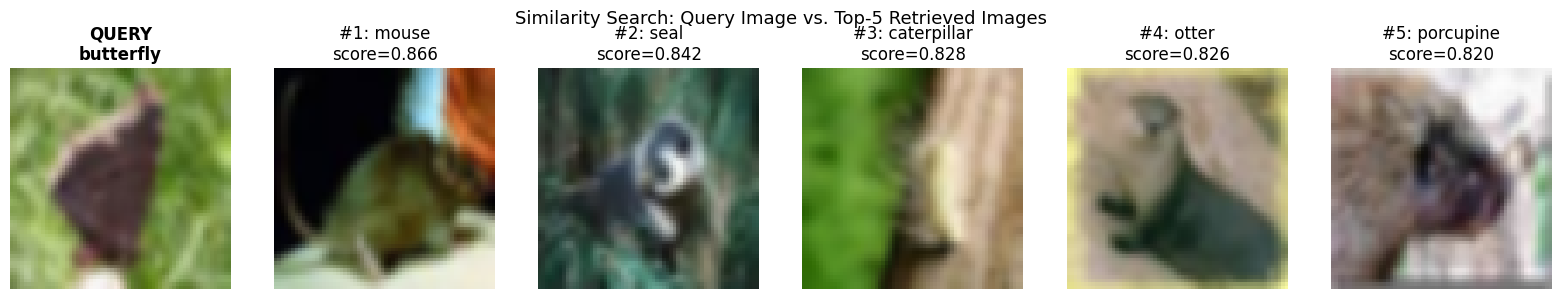

In [ ]:
# Pick a query image NOT in the gallery, and find its nearest neighbors
query_idx = random.choice([i for i in range(len(test_set)) if i not in gallery_indices])
query_img_tensor, query_label = test_set[query_idx]

with torch.no_grad():
    query_vec = model(query_img_tensor.unsqueeze(0).to(DEVICE), return_embedding=True).cpu().numpy()[0]

query_vec = query_vec.astype("float32").reshape(1, -1)
faiss.normalize_L2(query_vec)

K = 5
scores, indices = index.search(query_vec, K)

# Display query + top-K results
fig, axes = plt.subplots(1, K + 1, figsize=(16, 3))

axes[0].imshow(denormalize(query_img_tensor))
axes[0].set_title(f"QUERY\n{class_names[query_label]}", fontweight="bold")
axes[0].axis("off")

for rank, (score, idx) in enumerate(zip(scores[0], indices[0])):
    axes[rank + 1].imshow(denormalize(gallery_images[idx]))
    axes[rank + 1].set_title(f"#{rank+1}: {class_names[gallery_labels[idx]]}\nscore={score:.3f}")
    axes[rank + 1].axis("off")

plt.suptitle("Similarity Search: Query Image vs. Top-5 Retrieved Images", fontsize=13)
plt.tight_layout()
plt.show()


## 8. Save the Trained Model

In [ ]:
# The model was already saved during training as embedding_model.pth
# (best checkpoint by test accuracy). Confirm it's there:
import os
print("Checkpoint file exists:", os.path.exists("embedding_model.pth"))
print("File size (MB):", round(os.path.getsize("embedding_model.pth") / 1e6, 2))

# Download it to your computer
from google.colab import files
files.download("embedding_model.pth")


Checkpoint file exists: True
File size (MB): 8.17


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Optional: save a copy to Google Drive for safekeeping
# from google.colab import drive
# drive.mount('/content/drive')
# import shutil
# shutil.copy("embedding_model.pth", "/content/drive/MyDrive/embedding_model.pth")
# print("Saved to Google Drive")


## 9. Summary

| Item | Value |
|---|---|
| Dataset | CIFAR-100 (100 classes, 60,000 images) |
| Architecture | Custom CNN (4 conv blocks + embedding layer) |
| Embedding size | 256 |
| Trainable parameters | printed in Section 3 |
| Best test accuracy | printed in Section 4 |
| Output | `embedding_model.pth` — usable with `embedding_model.py`, `build_index.py`, and `retrieval.py` in the main retrieval project |

This notebook shows every step of building the image-vectorization
model from scratch: dataset understanding, architecture design,
training with monitored metrics, and validation that the resulting
vectors are meaningful (via t-SNE clustering and a working similarity
search demo).